# Семинар 13

# Stochastic Optimization 3: Methods with Adaptive Step

In [1]:
import numpy as np
import copy
import time
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import torch
from torch import nn
from torch.optim import Optimizer

In [3]:
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [4]:
matplotlib.use('Agg')
params = {'legend.fontsize': 20,
          'legend.handlelength': 4,
          "axes.labelsize": 45,
          "xtick.labelsize": 25,
          "ytick.labelsize": 25,
          "lines.linewidth": 4,
           "axes.titlesize":30}
matplotlib.rcParams.update(params)

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
device

device(type='cuda', index=0)

#### Классификация изображений рукописных цифр из MNIST датасета

In [6]:
transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((28,28)),
        torchvision.transforms.ToTensor(),
    ])

train_dataset = datasets.MNIST(root='./data',
                            train=True, download=True,
                            transform=transform)
test_dataset = datasets.MNIST(root='./data',
                           train=False, download=True,
                           transform=transform)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:10<00:00, 904kB/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 56.2kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.59MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [7]:
X_ = []
Y_ = []
for x, y in train_dataset:
    X_.append(x)
    Y_.append(y)
X = torch.stack(X_).to(device)
Y = torch.tensor(Y_).view(-1).to(device)

In [8]:
X_ = []
Y_ = []
for x, y in test_dataset:
    X_.append(x)
    Y_.append(y)
X_test = torch.stack(X_).to(device)
Y_test = torch.tensor(Y_).view(-1).to(device)

In [9]:
print("Shape of X train", X.shape)
print("Shape of X test", X_test.shape)
print("Sparsity of X train", (torch.sum(torch.abs(X)>=1e-12)/(X.shape[0] * X.shape[1])).item())

Shape of X train torch.Size([60000, 1, 28, 28])
Shape of X test torch.Size([10000, 1, 28, 28])
Sparsity of X train 149.90260314941406


### Модель

$$F_{W_1\dots W_n} (\mathbf{x}) = \text{Softmax}\left(W_n\sigma\left(W_{n-1}\dots \sigma\left(W_1 \mathbf{x}\right)\dots \right)\right),$$
где $\sigma$ - некоторая функция активации,

$$\text{Softmax}(\mathbf{x}) = \frac{e^\mathbf{x}}{\sum\limits_{i=1}^n e^{x_i}}$$

In [10]:
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5)
        self.conv3 = nn.Conv2d(32,64, kernel_size=5)
        self.fc1 = nn.Linear(3*3*64, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        #x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv3(x),2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.view(-1,3*3*64 )
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x

In [11]:
model = CNN()
model.to(device)
model

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [12]:
print("Sum of the first raw of model(x[0])", torch.sum(model(X_test)[0]))
print("Shape of X test", X_test.shape)
print("Shape of X test", model(X_test).shape)

Sum of the first raw of model(x[0]) tensor(-0.0014, device='cuda:0', grad_fn=<SumBackward0>)
Shape of X test torch.Size([10000, 1, 28, 28])
Shape of X test torch.Size([10000, 10])


In [13]:
def get_batch_indexes(n, batch_size):
    """
    :param batch_size: int, batch size
    :param n: int, the size of full dataset
    :return: list of batches
    """
    indexes = np.arange(n)
    indexes = np.random.permutation(indexes)
    batches = np.array_split(indexes, n//batch_size)
    return batches


def update_logs(logs, iteration, train_loss, test_loss, time_val):
    """
    :param logs: dict, dictionary for logs
    :param iteration: int, number of iteration
    :param train_loss: float, value of loss on train dataset
    :param test_loss: float, value of loss on test dataset
    :param time_val: float, time from training start
    :return:
    """
    logs['iter'].append(iteration)
    logs['train_loss'].append(train_loss)
    logs['test_loss'].append(test_loss)
    logs['time'].append(time_val)


def train_epochs(model, X, Y, loss, num_epochs,
          optimizer, batch_size,
          scheduler=None, scheduler_in_batch=False,
          X_test=None, Y_test=None):
    """
    :param model: nn.Module, model that should be trained
    :param X: torch.tensor, train dataset, input of model
    :param Y: torch.tensor, train dataset, target for model
    :param loss: callable, that takes model output with target and returns differntiable loss
    :param num_epochs: int, number of epochs
    :param optimizer: optimizer with method step
    :param batch_size: int, batch size
    :param scheduler: scheduler that change lr size
    :param X_test: torch.tensor, test dataset, input of model
    :param Y_test: torch.tensor, test dataset, target for model
    :return: trained model and logs
    """
    n = X.shape[0]
    logs = defaultdict(list)
    t0 = time.time()
    num_iters = 0
    for i in range(num_epochs):
        batches = get_batch_indexes(n, batch_size)
        for batch in batches:
            X_batch, Y_batch = X[batch], Y[batch]
            loss_value = loss(model(X_batch), Y_batch.long())
            loss_value.backward()
            optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None and scheduler_in_batch:
                scheduler.step(epoch=num_iters)
            num_iters+=1
        with torch.no_grad():
            train_loss = loss(model(X), Y.long()).cpu().item()
            if X_test is not None:
                test_loss = loss(model(X_test), Y_test.long()).cpu().item()
            else:
                test_loss = None
        if scheduler is not None and not scheduler_in_batch:
            print(i, scheduler.get_last_lr(), train_loss)
            scheduler.step(epoch=i)
        update_logs(logs, i, train_loss, test_loss, time.time() - t0)
    return model, logs

In [14]:
def plot_logs(logs_dict_vr):
    plt.figure(figsize=(30, 20))
    fig, ax = plt.subplots(1, 2, figsize=(30, 10))
    y_min = None
    for label, logs in logs_dict_vr.items():
        ax[0].semilogy(logs["iter"], logs["train_loss"], label=label)
        ax[1].semilogy(logs["iter"], logs["test_loss"], label=label)
        if y_min is None or y_min > min(logs["test_loss"]):
            y_min = min(logs["test_loss"])
    ax[0].legend()
    ax[0].set_ylabel("Function Value")
    ax[0].set_xlabel("Epoch")
    ax[0].set_title("Loss on Train")
    ax[0].grid()
    ax[1].legend()
    ax[1].set_ylabel("Function Value")
    ax[1].set_xlabel("Epoch")
    ax[1].set_title("Loss on Test")
    ax[1].axhline(y=y_min, color='r', linestyle='--')
    ax[1].grid()

**SGD with momentum:**

$$x_{k+1} = x_k - \alpha_k \nabla f_i(x_k) + \beta (x_{k}-x_{k-1}),$$
or

$$v_{k} =  \nabla f_i(x_k) + \tilde{\beta} v_{k-1}$$

$$x_{k+1} = x_k -\alpha_k v_k$$

Схемы выше эквивалентны, если $\alpha_k \tilde{\beta} = \beta.$

**SGD with Nesterov momentum**

$$y_{k} = x_k - \alpha^k \tilde{\beta} v_{k-1}$$

$$v_{k} = \nabla f_i(y_{k}) + \tilde{\beta} v_{k-1}$$

$$x_{k+1} = y_{k} - \alpha (v_k - \tilde{\beta}v_{k-1})$$


Рассмотрим $y_{k+1}$
$$y_{k+1} = x_{k+1} - \alpha \tilde{\beta} v_{k}=y_k-\alpha (v_{k}-\tilde{\beta}v_{k-1}+\tilde{\beta} v_k) = y_k-\alpha (\nabla f_i(y_{k})+\tilde{\beta} (\nabla f_i(y_{k}) + v_{k-1}))$$

Обновление, не содержащее $x$:

$$v_{k} = \nabla f_i(y_{k}) + \tilde{\beta} v_{k-1}$$

$$\tilde{v}_{k} = \nabla f_i(y_{k}) + \tilde{\beta} v_{k}$$

$$y_{k+1} = y_{k} - \alpha \tilde{v}_k$$

In [15]:
from torch.optim import SGD

In [16]:
epochs = 100
batch_size = 256

In [17]:
logs_dict_vr = {}

In [18]:
model=CNN()
model.to(device)
model.to(torch.float32)
optimizer = SGD(model.parameters(), lr=0.05)
_, logs_dict_vr["SGD"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

In [19]:
model=CNN()
model.to(device)
model.to(torch.float32)
optimizer = SGD(model.parameters(), lr=0.05, momentum=0.8)
_, logs_dict_vr["SGD, momentum"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

In [20]:
model=CNN()
model.to(device)
model.to(torch.float32)
optimizer = SGD(model.parameters(), lr=0.05, momentum=0.8, nesterov=True)
_, logs_dict_vr["SGD, Nesterov Momentum"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

<Figure size 3000x2000 with 0 Axes>

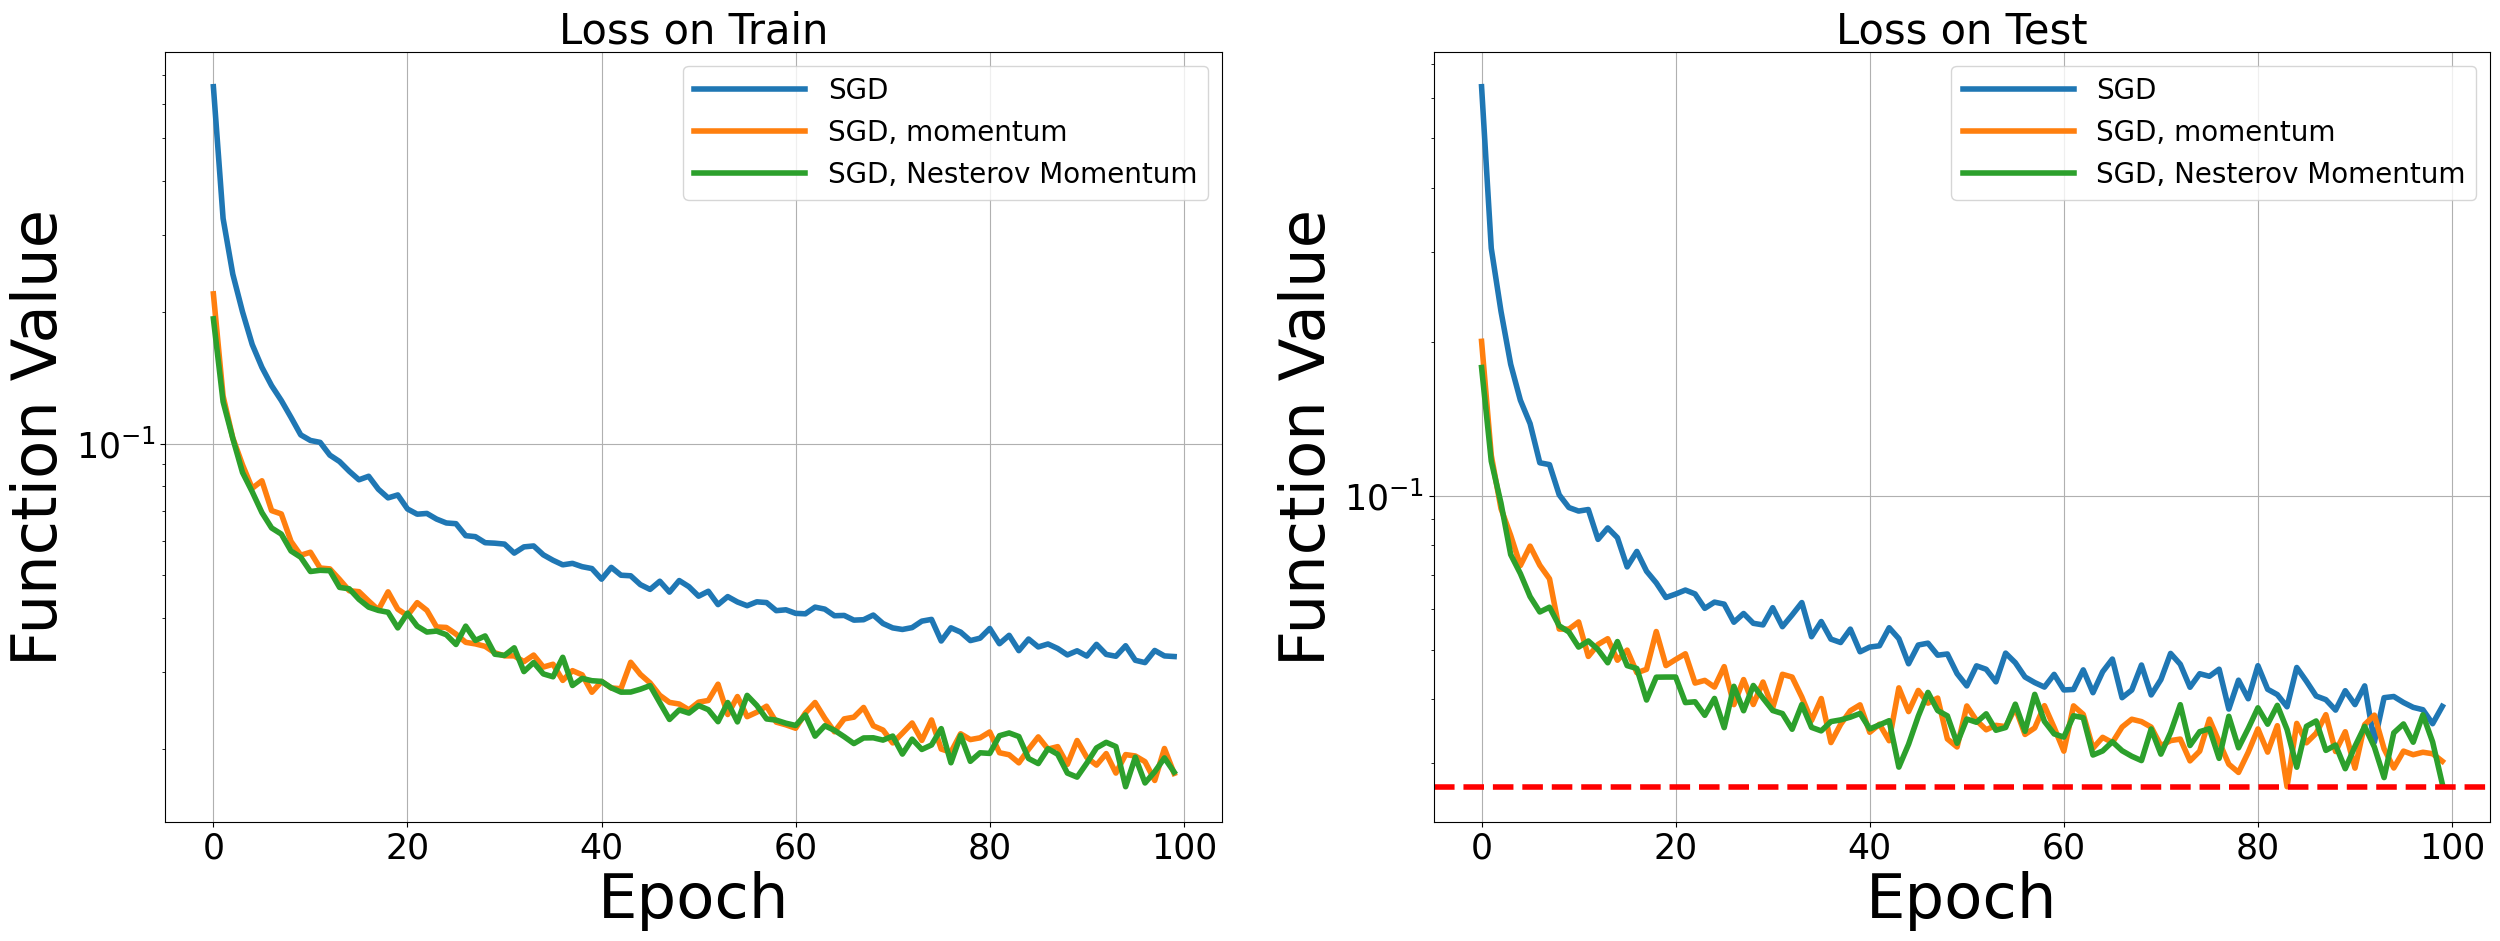

In [21]:
%matplotlib inline
plot_logs(logs_dict_vr)

## 1. Адаптивные стохастические методы

### 1.1. The Adaptive Gradient Algorithm (AdaGrad): normalization (2011)

$$g_{i_k} = \nabla f_{i_k}(x)$$
$$\mathbf{r}_{k} = \mathbf{r}_{k-1} + g_{i_k} \cdot g_{i_k} - \text{Аккумуляция квадратов градиентов}$$
$$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha \frac{\mathbf{g}_{i_k}}{\sqrt{\mathbf{r}_k} + \epsilon} - \text{Шаг SGD с отнормированным шагом}$$

Параметры метода: learning rate ($\alpha$), $\epsilon$

### 1.2. RMSprop: exp.average for normalization

$$\mathbf{g}_{i_k} = \nabla f_{i_k}(x)$$
$$\mathbf{r}_{k} = \rho \mathbf{r}_{k-1} + (1-\rho) \mathbf{g}_{i_k} \cdot \mathbf{g}_{i_k} - \text{Аккумуляция квадратов градиентов  с коэффициентом $\rho\in[0,1]$}$$

$$\Delta x_k = \frac{\mathbf{g}_{i_k}}{\sqrt{\mathbf{r}_k + \epsilon}}  $$
$$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha \Delta x_k - \text{Шаг SGD с отнормированным шагом}$$

Параметры метода: learning rate ($\alpha$), decay ($\rho$), $\epsilon$

### 1.3. AdaDelta (2012)

$$\mathbf{g}_{i_k} = \nabla f_{i_k}(x)$$
$$\mathbf{r}_{k} = \rho \mathbf{r}_{k-1} + (1-\rho) \mathbf{g}_{i_k} \cdot \mathbf{g}_{i_k} - \text{Аккумуляция квадратов градиентов  с коэффициентом $\rho\in[0,1]$}$$
$$\Delta \mathbf{x}_{k} = \frac{\sqrt{\mathbf{u}_{k-1} + \epsilon}}{\sqrt{\mathbf{r}_k + \epsilon}} \mathbf{g}_{i_k},$$

$$\mathbf{u}_{k} = \rho \mathbf{u}_{k-1} + (1-\rho) \Delta \mathbf{x}_k \cdot \Delta \mathbf{x}_k$$

$$\mathbf{x}_{k+1} = x_k - \alpha \Delta \mathbf{x}_{k}$$

Параметры метода: learning rate ($\alpha$), decay ($\rho$), $\epsilon$

$\mathbb{E}g_{i_k}=g$

$\mathbb{E}m_k=(1-\beta_1)\sum_{j=0}^{k-1}\beta_1^j g = (1-\beta_1^k)g$

### 1.4 Adam: RmsProp + momentum + correction (v1. 2014)

Запоминает не только предыдущие размеры шага, но и предыдущие направления:

$$\mathbf{m}_k = \beta_1 \mathbf{m}_{t-1} + (1-\beta_1) \mathbf{g}_{i_k} - \text{Обновление оценки первого момента}$$

$$\mathbf{v}_k = \beta_2 \mathbf{v}_{t-1} + (1-\beta_2) \mathbf{g}_{i_k}^2 - \text{Обновление оценки второго момента}$$

Корректировка смещения:

$$\hat{\textbf{m}}_k = \frac{\textbf{m}_k}{1-\beta_1^k}$$

$$\hat{\mathbf{v}}_k = \frac{\mathbf{v}_k}{1-\beta_2^k}$$

Шаг метода:

$$\Delta x_k = \frac{1}{\sqrt{\hat{\mathbf{v}}_k + \varepsilon}}\hat{\textbf{m}}_k$$

$$x_{k+1} = x_k - \alpha \Delta x_k$$

Сходимость методов: https://ruder.io/content/images/2016/09/contours_evaluation_optimizers.gif

In [22]:
from torch.optim import Adadelta, Adagrad, RMSprop, Adam

In [23]:
model = CNN()
model.to(device)
model.to(torch.float32)
optimizer = Adagrad(model.parameters(), lr=0.005)
_, logs_dict_vr["Adagrad"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

In [24]:
model = CNN()
model.to(device)
model.to(torch.float32)
optimizer = Adadelta(model.parameters(), lr=5e-1)
_, logs_dict_vr["Adadelta"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

In [25]:
model = CNN()
model.to(device)
model.to(torch.float32)
optimizer = RMSprop(model.parameters(), lr=5e-4)
_, logs_dict_vr["RMSprop"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

In [26]:
model = CNN()
model.to(device)
model.to(torch.float32)
optimizer = Adam(model.parameters(), lr=5e-4)
_, logs_dict_vr["Adam"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

<Figure size 3000x2000 with 0 Axes>

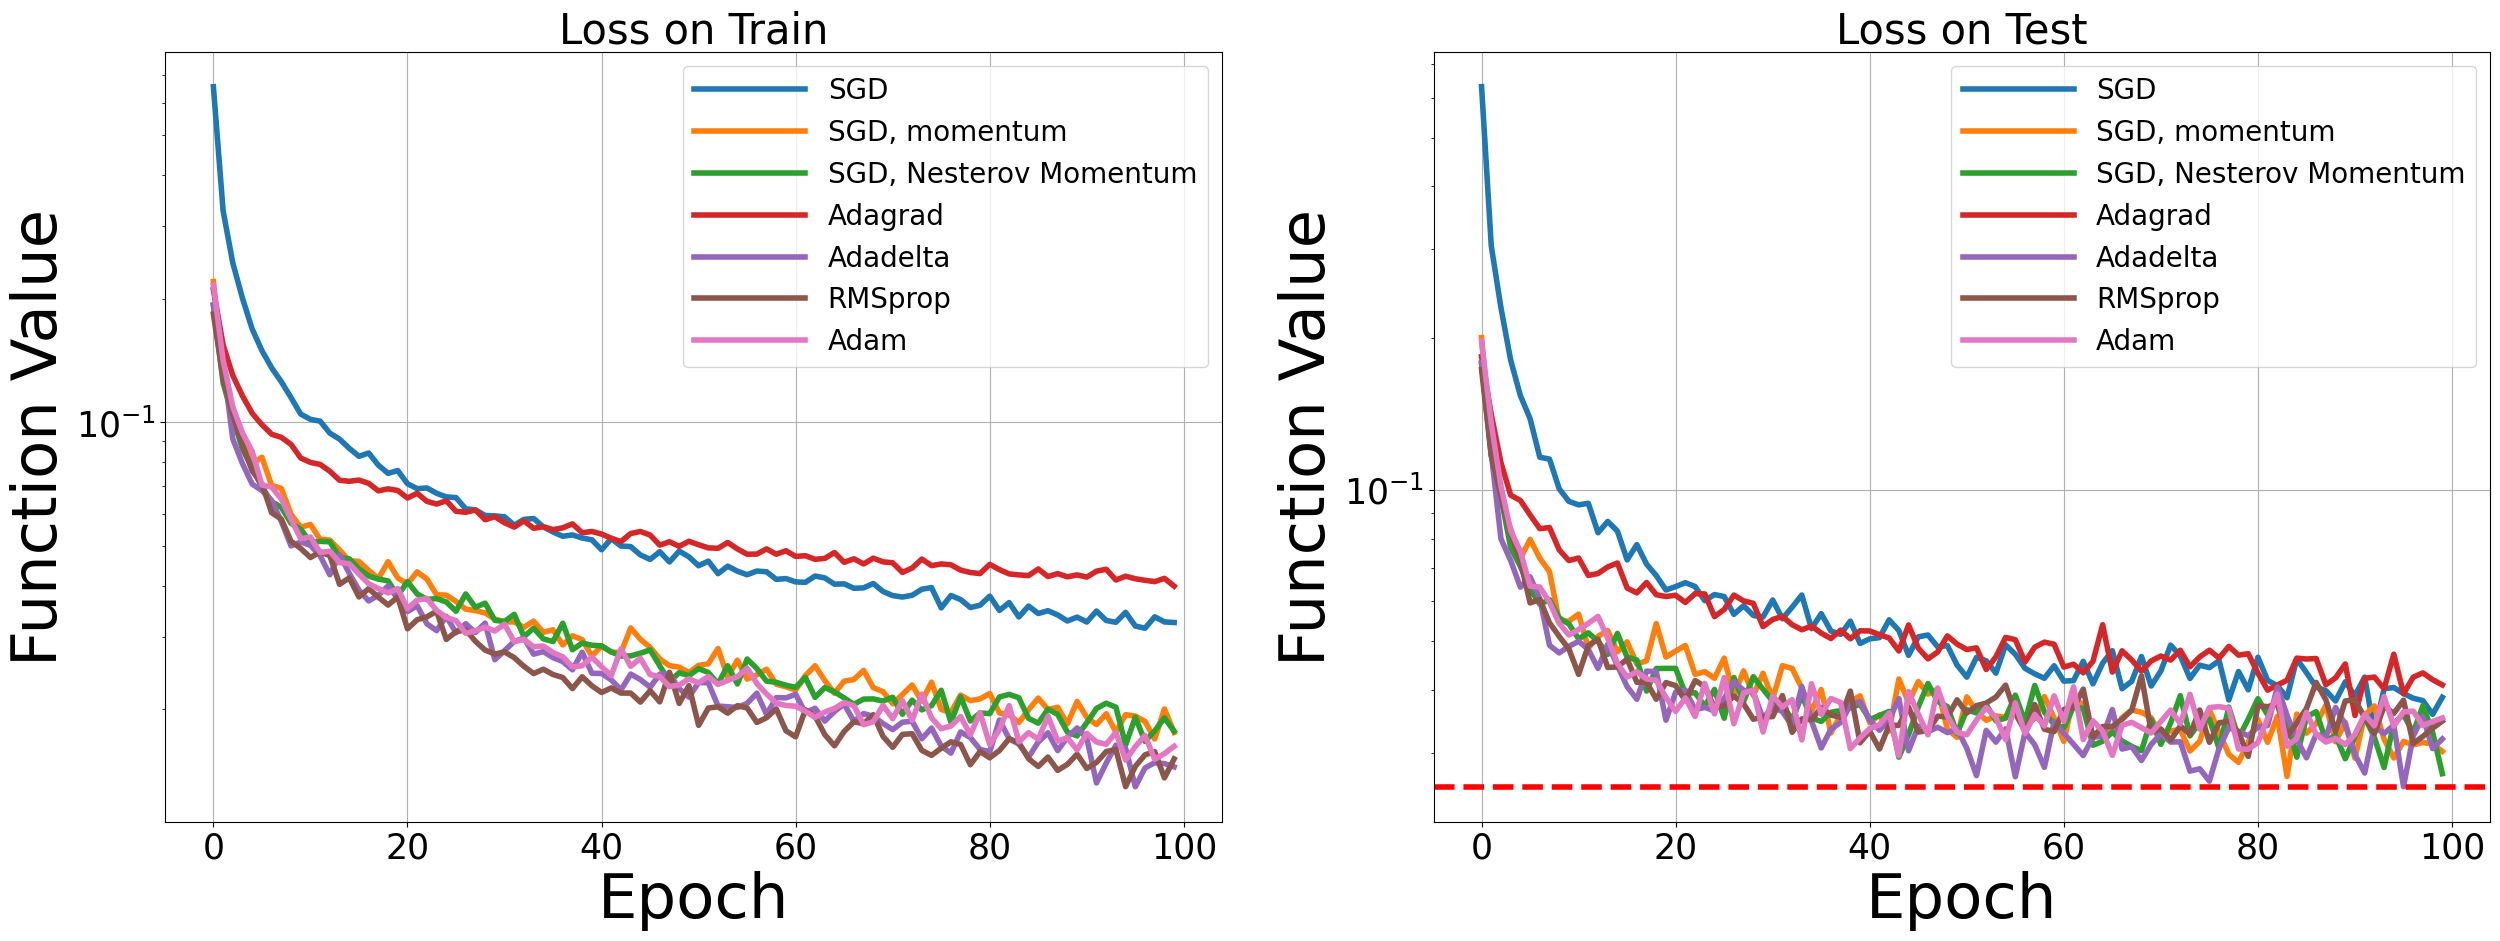

In [27]:
%matplotlib inline
plot_logs(logs_dict_vr)

In [28]:
logs_dict_vr = {}
lr_list = [5e-1, 5e-2, 5e-3, 5e-4, 5e-5]
for lr in lr_list:
    model = CNN()
    model.to(device)
    model.to(torch.float32)
    optimizer = Adam(model.parameters(), lr=lr)
    _, logs_dict_vr["Adam, lr={}".format(lr)] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

<Figure size 3000x2000 with 0 Axes>

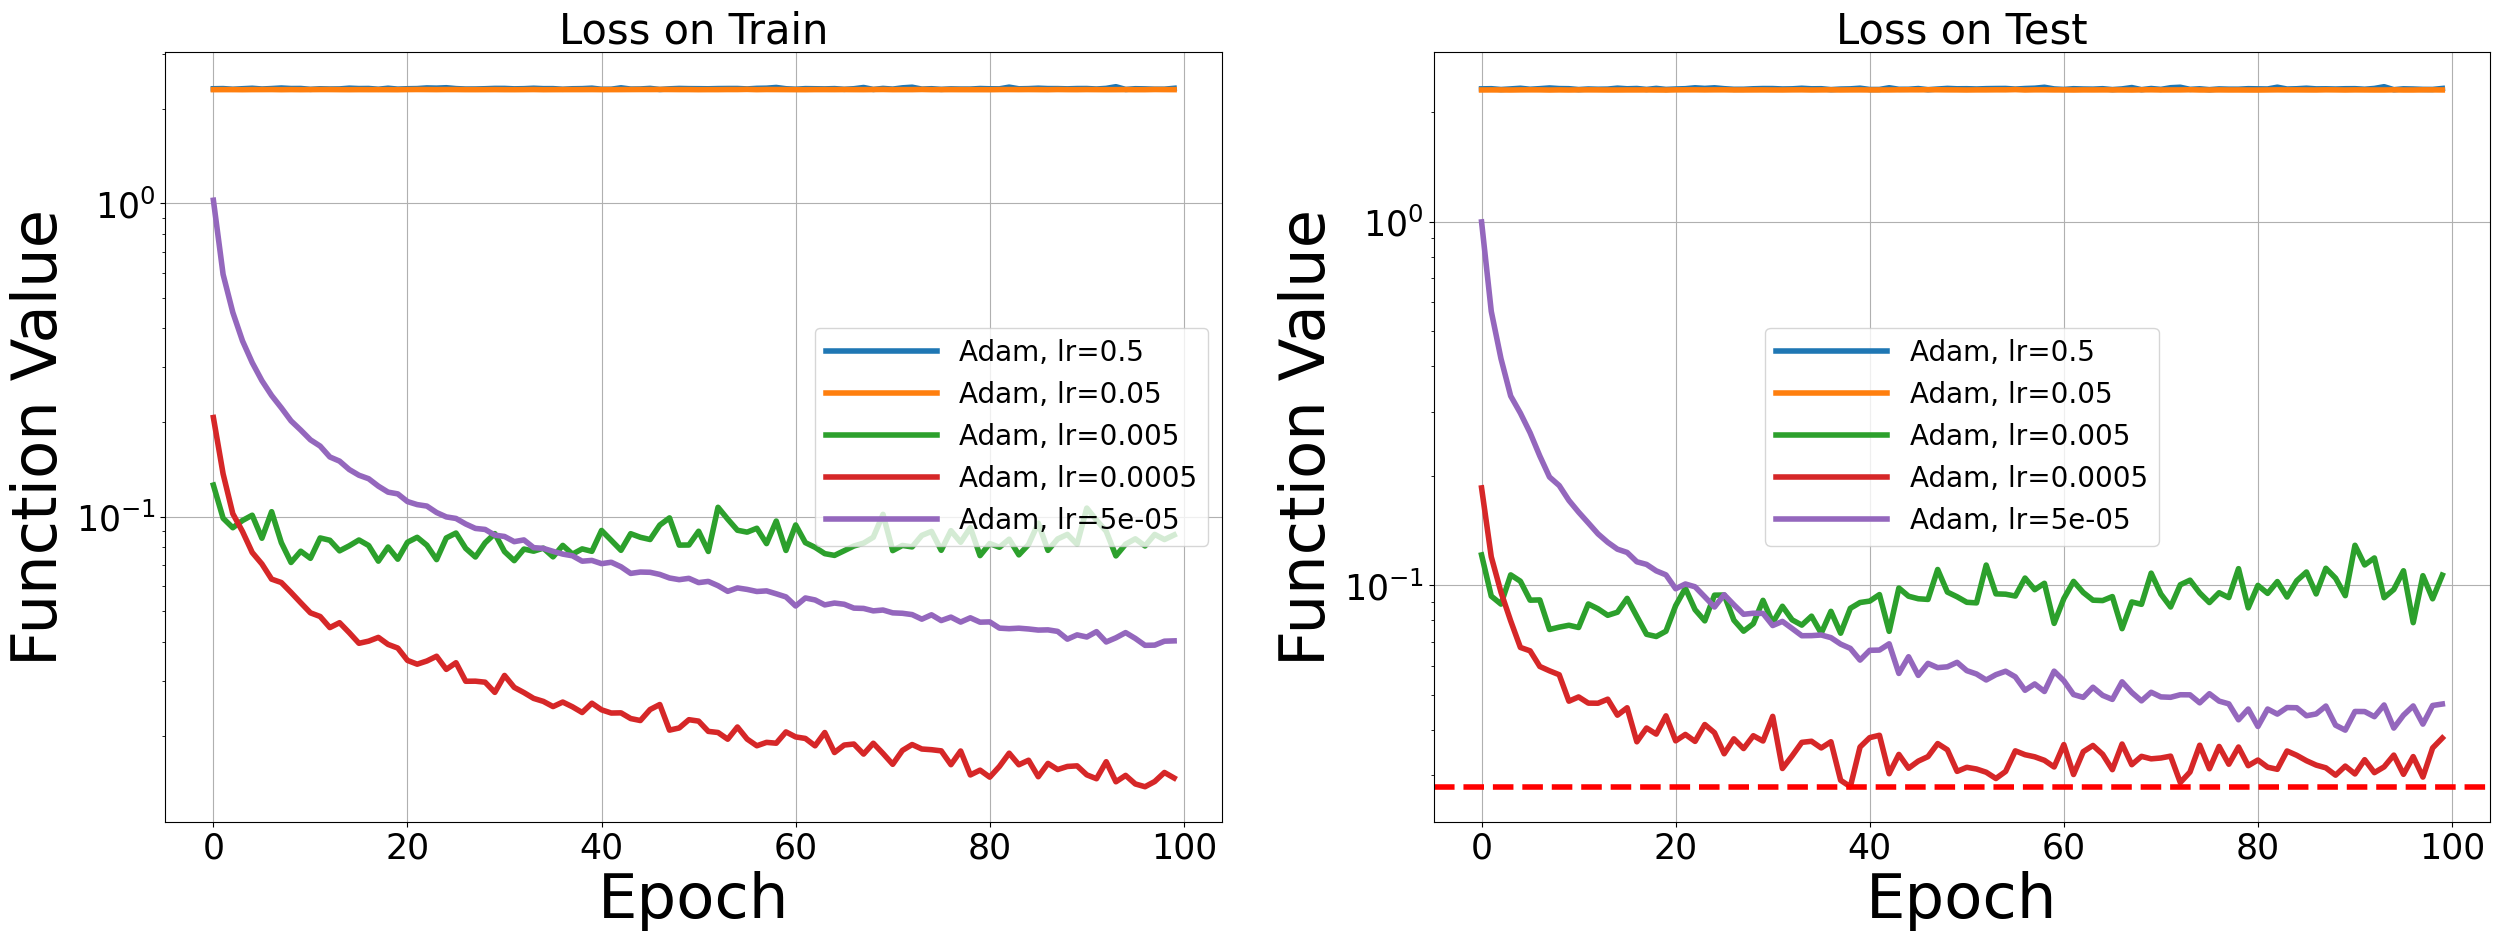

In [29]:
%matplotlib inline
plot_logs(logs_dict_vr)

In [31]:
logs_dict_vr = {}
batch_size_list = [64, 128, 256, 512]
for batch_size in batch_size_list:
    model = CNN()
    model.to(device)
    model.to(torch.float32)
    optimizer = Adam(model.parameters(), lr=5e-4)
    _, logs_dict_vr["Adam, batch_size={}".format(batch_size)] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

<Figure size 3000x2000 with 0 Axes>

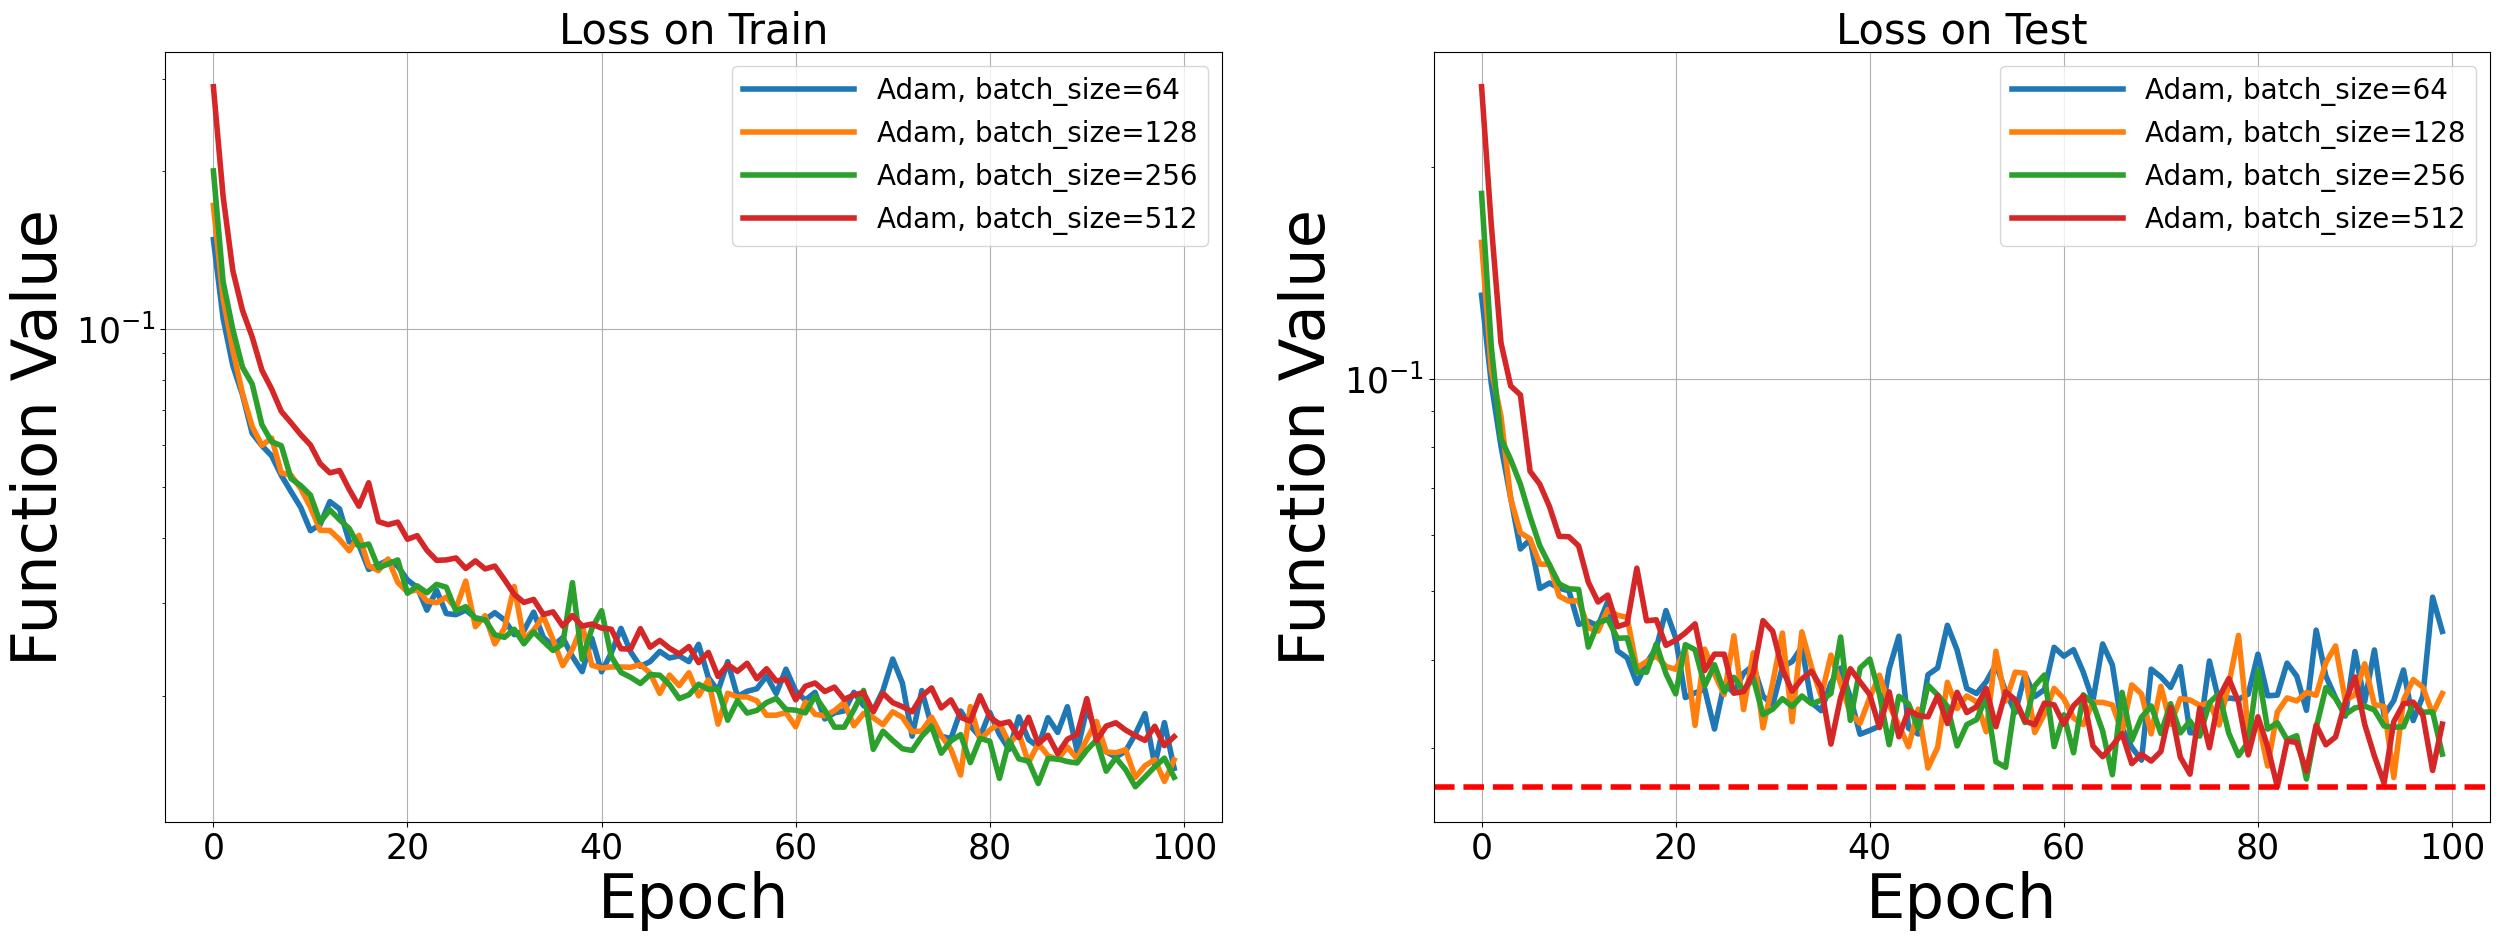

In [32]:
%matplotlib inline
plot_logs(logs_dict_vr)